# Brain Tumor Detection Using Transfer Learning (VGG16) with TensorFlow & Keras

### `Importing Dependencies`

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import random
from PIL import Image, ImageEnhance
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize

I0000 00:00:1784269298.573620   20187 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784269298.601136   20187 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784269299.349473   20187 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### `Loading Datasets`

In [4]:
train_dir = "dataset/data/Training"
test_dir = "dataset/data/Testing"

train_paths = []
train_labels = []

for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append((os.path.join(train_dir, label, image)))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

test_paths = []
test_labels = []

for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append((os.path.join(test_dir, label, image)))
        test_labels.append(label)
test_paths, test_labels = shuffle(test_paths, test_labels)

print(os.listdir(train_dir))
import json
import os

CLASS_NAMES = os.listdir(train_dir)

with open("model/classes.json", "w") as f:
    json.dump(CLASS_NAMES, f)

print(CLASS_NAMES)

['glioma', 'pituitary', 'meningioma', 'notumor']
['glioma', 'pituitary', 'meningioma', 'notumor']


### `Data Visualization`

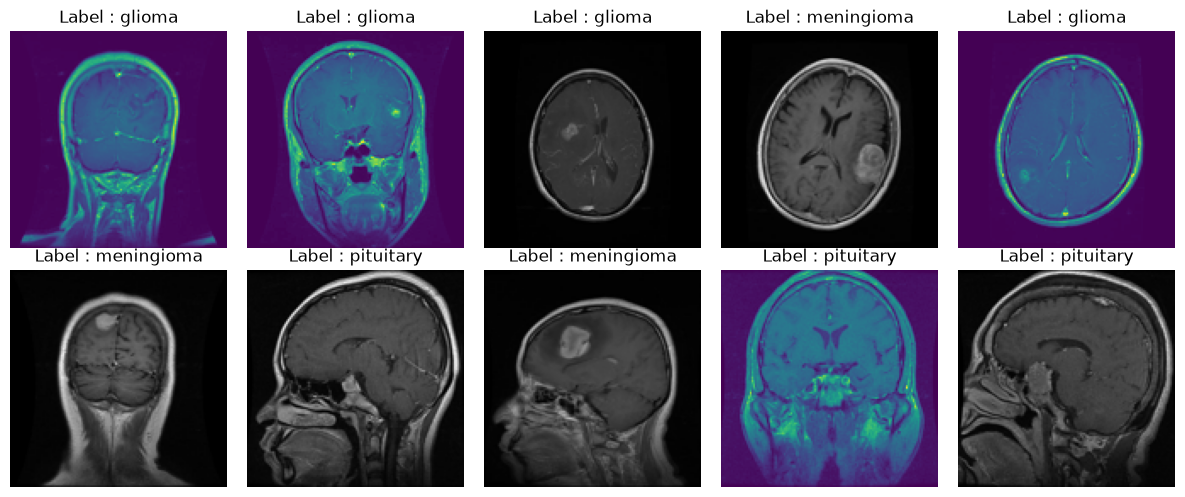

In [5]:
random_indices = random.sample(range(len(train_paths)), 10)

fig, axes = plt.subplots(2, 5, figsize = (12,5))
axes = axes.ravel()

for i, idex in enumerate(random_indices):
    img_path = train_paths[idex]
    img = Image.open(img_path)
    img = img.resize((128,128))

    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"Label : {train_labels[idex]}")

plt.tight_layout()
plt.show()

### `Image Preprocessing`

In [6]:
def augement_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8,1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8,1.2))
    image = np.array(image) / 255.0
    return image

def open_images(paths):
    images=[]
    for path in paths:
        img = load_img(path, target_size=(Image_SIZE, Image_SIZE))
        img = augement_image(img)
        images.append(img)
    return np.array(images)

def encode_labels(labels):
    unique_labels = os.listdir(train_dir)
    return np.array([unique_labels.index(label) for label in labels], dtype=np.int32)
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i+batch_size]
            batch_images = open_images(batch_paths)
            batch_labels = labels[i:i+batch_size]
            batch_labels = encode_labels(batch_labels)
            yield batch_images, batch_labels

### `Model Architechture`

In [7]:
Image_SIZE = 128
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(Image_SIZE, Image_SIZE,3))

for layer in base_model.layers:
    layer.trainable=False

base_model.layers[-2].trainable = False
base_model.layers[-3].trainable = False
base_model.layers[-4].trainable = False

model = Sequential()
model.add(Input(shape = (Image_SIZE, Image_SIZE, 3)))
model.add(base_model)
model.add(Flatten())
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))

model.compile(
    optimizer=Adam(learning_rate=0.0001), 
    loss = 'sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

batch_size = 20
steps = int(len(train_paths)/batch_size)
epochs=20

history = model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
    steps_per_epoch=steps,
    epochs=epochs
)

I0000 00:00:1784202141.859424   11052 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4134 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Epoch 1/20


/home/riku/pyvn/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a generator. The generator is expected to yield already-shuffled data.
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1784202142.733379   11052 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1784202143.244293   11235 service.cc:153] XLA service 0x7b4c80034600 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784202143.244310   11235 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1784202143.269734   11235 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1784202143.447252   11235 cuda_dnn.cc:461

  7/280 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 1.8253 - sparse_categorical_accuracy: 0.2714

I0000 00:00:1784202149.201813   11235 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


280/280 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - loss: 0.7040 - sparse_categorical_accuracy: 0.7268
Epoch 2/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - loss: 0.4230 - sparse_categorical_accuracy: 0.8436
Epoch 3/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - loss: 0.3555 - sparse_categorical_accuracy: 0.8645
Epoch 4/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - loss: 0.3249 - sparse_categorical_accuracy: 0.8788
Epoch 5/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - loss: 0.2847 - sparse_categorical_accuracy: 0.8938
Epoch 6/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - loss: 0.2664 - sparse_categorical_accuracy: 0.8966
Epoch 7/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - loss: 0.2505 - sparse_categorical_accuracy: 0.9052
Epoch 8/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - loss: 0.2351 - sparse_categorical_accuracy: 0.9127
Epoch 9/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - loss: 0.2253 - sparse_categorical_accuracy: 0.9168
Epoch 10/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - 

### `Train and val plots`

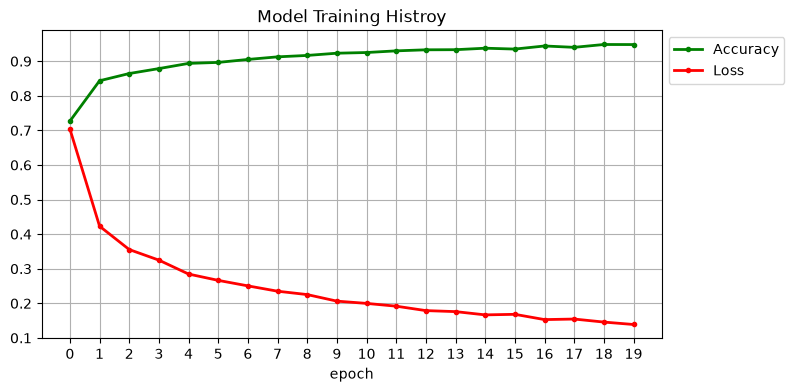

In [8]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'],'.g-', linewidth=2)
plt.plot(history.history['loss'],'.r-', linewidth=2)
plt.title('Model Training Histroy')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1,1))
plt.show()

### `Model Classification Report`

In [9]:
test_images = open_images(test_paths)
test_labels_encoded = encode_labels(test_labels)

test_prediction = model.predict(test_images)
print("Classification Report: ")
print(classification_report(test_labels_encoded, np.argmax(test_prediction, axis=1)))

50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step
Classification Report: 
              precision    recall  f1-score   support

           0       0.95      0.73      0.82       400
           1       0.98      0.95      0.96       400
           2       0.79      0.92      0.85       400
           3       0.91      1.00      0.95       400

    accuracy                           0.90      1600
   macro avg       0.91      0.90      0.90      1600
weighted avg       0.91      0.90      0.90      1600



### `Confusion Matrix`

Confusion Matrix: 
[[292   0  77  31]
 [  1 379  19   1]
 [ 15   9 369   7]
 [  0   0   1 399]]


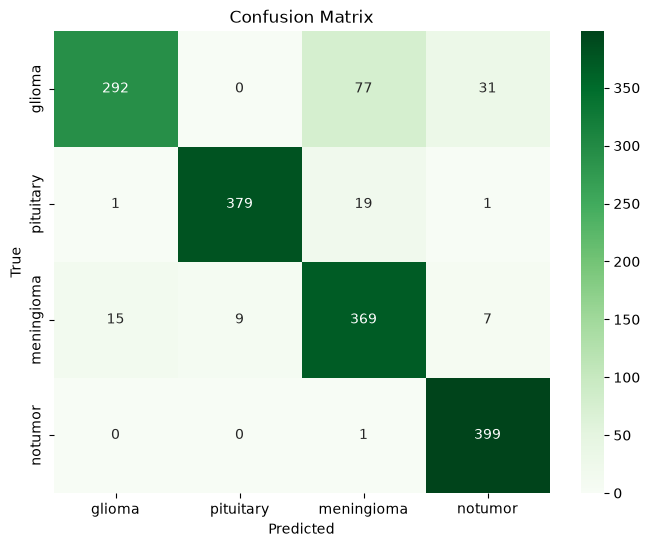

In [13]:
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_prediction, axis = 1))
print("Confusion Matrix: ")
print(conf_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt ='d', cmap="Greens", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### `ROC Curve Line`

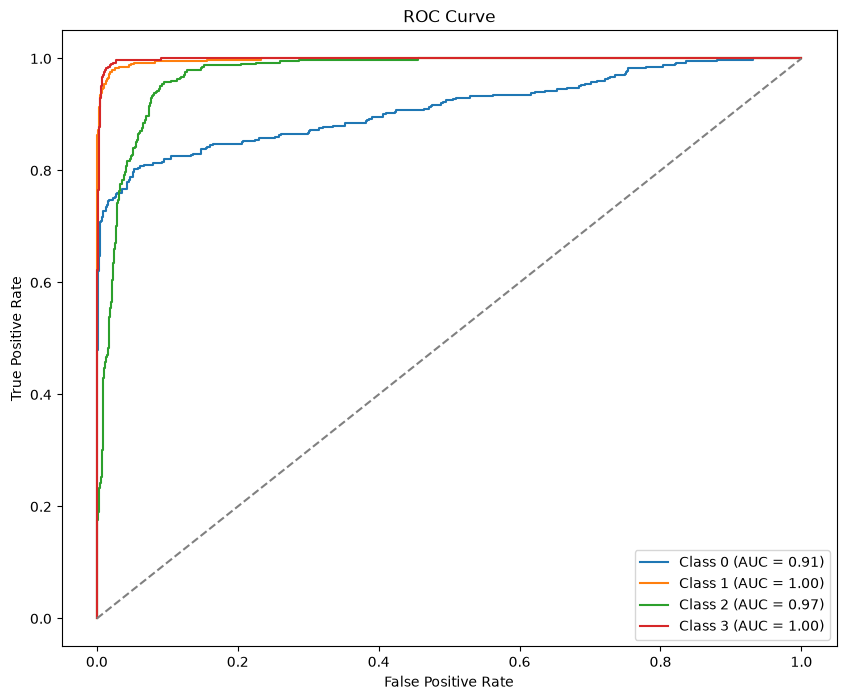

In [17]:
test_labels_bin = label_binarize(
    test_labels_encoded,
    classes=np.arange(len(os.listdir(train_dir)))
)
test_predictions_bin = test_prediction
fpr, tpr, roc_auc = {}, {}, {}

for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(
        test_labels_bin[:, i],
        test_predictions_bin[:, i]
    )
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))

for i in range(len(os.listdir(train_dir))):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f'Class {i} (AUC = {roc_auc[i]:.2f})'
    )

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

### `Saving Model`

In [19]:
model.save('monco.keras')

In [23]:
from tensorflow.keras.models import load_model

model = load_model('/model/monco.keras')

/home/riku/pyvn/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'rm_sprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


### `Model Detection System`

In [30]:
from keras.utils import load_img, img_to_array

class_labels = ['pituitary', 'glioma', 'notumor', 'meningioma']

def detect_and_display(image_path, model):
    try:
        img = load_img(img_path, target_size = (128, 128) )
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)

        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions)
        confidence_score = np.max(predictions, axis=1)[0]

        if class_labels[predicted_class_index] == 'notumor':
            result = 'No Tumor Detected'
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"
        
        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f'{result} (Confidence:) {confidence_score * 100:.2f}%') 
        plt.show()
    except Exception as e:
        print(e)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


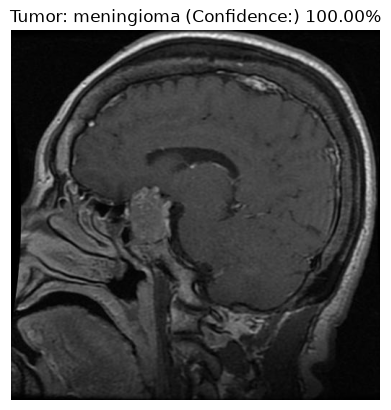

In [31]:
image_path  = 'dataset/data/Testing/meningioma/Te-me_293.jpg'
detect_and_display(image_path, model)

### `Project Owner - Manabendu karfa`